In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, classification_report
from sklearn.inspection import permutation_importance
import scipy.stats as stats
from catboost import CatBoostRegressor, Pool, CatBoostClassifier

In [3]:
df = pd.read_csv('/content/df_train_2_FE.csv')

df_val = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_2_FE_sinOutliers.csv')

df.dropna(inplace=True)

df['key'] = df['key'].astype(str)
df['mode'] = df['mode'].astype(str)
df['grupo_anio'] = df['grupo_anio'].astype(str)
df['len_playlist_name'] = df['len_playlist_name'].astype(str)
df['tonality'] = df['tonality'].astype(str)

df['distance_mean_duration_min'] = (df['duration_min'] - df['duration_min'].mean())
df['distance_sq_mean_duration_min'] = (df['distance_mean_duration_min'])**2
df['log_duration_min'] = np.log(df['duration_min'])
df['z_duration_min'] = (df['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

# FE de tiempo
df['tiene_mes_y_dia'] = (df['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df.loc[df['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df['mes'] = 13
df.loc[df['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df['dia'] = 32
df.loc[df['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df['tiene_mes_y_dia'] = df['tiene_mes_y_dia'].astype(str)
df['mes'] = df['mes'].astype(str)
df['dia'] = df['dia'].astype(str)

df_val['tiene_mes_y_dia'] = (df_val['track_album_release_date'].apply(lambda x: x.count('-')) == 2).astype(int)
serie_tiempo = pd.to_datetime(df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'track_album_release_date'])
df_val['mes'] = 13
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'mes'] = serie_tiempo.dt.month
df_val['dia'] = 32
df_val.loc[df_val['tiene_mes_y_dia'] == 1, 'dia'] = serie_tiempo.dt.day
df_val['tiene_mes_y_dia'] = df_val['tiene_mes_y_dia'].astype(str)
df_val['mes'] = df_val['mes'].astype(str)
df_val['dia'] = df_val['dia'].astype(str)


df_val['log_duration_min'] = np.log(df_val['duration_min'])
df_val['z_duration_min'] = (df_val['duration_min'] - df['duration_min'].mean())/df['duration_min'].std()

### Adversarial Validation

Adversarial validation has been implemented in this notebook to address potential distribution shifts between the training data (`df`) and the validation data (`df_val`).

1.  A binary classification task is set up where a `CatBoostClassifier` (in cell `h3nymLJjjAlS`) is trained to distinguish between rows from `df` (labeled as 0) and rows from `df_val` (labeled as 1).
2.  The output probabilities from this classifier (specifically, the probability of a row from `df` being classified as `df_val`, i.e., class 1) are then used as sample weights for the subsequent `CatBoostRegressor` (in cell `h5PH_g8-kdN1`).

This approach helps the regression model focus more on the training samples that are structurally similar to the validation set, thereby making the model more robust to potential data distribution differences and potentially improving its generalization performance on the validation set.

In [5]:
df_classifier_train = df.copy()
df_classifier_val = df_val.copy()

df_classifier_train['is_kaggle_df'] = 0
df_classifier_val['is_kaggle_df'] = 1

df_combined_for_classification = pd.concat([df_classifier_train, df_classifier_val], ignore_index=True)

df_combined_for_classification = df_combined_for_classification.dropna(axis=1)

# Define features (X) and target (y)
y_clf = df_combined_for_classification['is_kaggle_df']

# Drop columns that are identifiers or have been processed into other features
# 'track_album_release_date' is dropped as its information is captured by 'tiene_mes_y_dia', 'mes', 'dia'
# 'track_id', 'track_name', 'artist_name', 'track_album_name', 'playlist_name', 'uri', 'url' are typically not used as direct features
features_to_drop = [
    'is_kaggle_df',
    'track_id',
    'track_name',
    'artist_name',
    'track_album_name',
    'track_album_release_date',
    'playlist_name',
    'playlist_id',
    'playlist_genre', 'playlist_subgenre', 'Unnamed: 0'
]
X_clf = df_combined_for_classification.drop(columns=features_to_drop, errors='ignore')
categorical_features_indices = X_clf.select_dtypes(include=['object', 'category']).columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print(f"Number of features for classification: {X_clf.shape[1]}")
print(f"Categorical features: {categorical_features_indices}")

# Initialize and train CatBoostClassifier
cat_clf = CatBoostClassifier(
    iterations=500,  # You can adjust this
    learning_rate=0.05, # You can adjust this
    depth=6,         # You can adjust this
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False, # Set to True for more detailed output during training
    cat_features=categorical_features_indices
)

print("Training CatBoost Classifier...")
cat_clf.fit(X_train, y_train)

print("CatBoost Classifier trained successfully.")

# You can now use cat_clf to make predictions or evaluate its performance
# For example, to get prediction probabilities:
# y_pred_proba = cat_clf.predict_proba(X_clf)

y_pred = cat_clf.predict(X_test)
print(f"Classification report:\n{classification_report(y_test, y_pred)}")

Number of features for classification: 86
Categorical features: ['track_artist', 'track_album_id', 'key', 'mode', 'grupo_anio', 'len_playlist_name', 'most_extreme_feature', 'tonality', 'tiene_mes_y_dia', 'mes', 'dia']
Training CatBoost Classifier...
CatBoost Classifier trained successfully.
Classification report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5222
           1       0.87      0.72      0.79      1344

    accuracy                           0.92      6566
   macro avg       0.90      0.85      0.87      6566
weighted avg       0.92      0.92      0.92      6566



Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     26261
           1       0.96      0.87      0.91      6567

    accuracy                           0.97     32828
   macro avg       0.96      0.93      0.95     32828
weighted avg       0.97      0.97      0.97     32828

In [6]:
pd.DataFrame(cat_clf.feature_importances_, index=X_clf.columns, columns=['importance']).sort_values('importance', ascending=False).head(15)

,importance
track_artist,17.366771
len_playlist_name,8.883401
grupo_anio,6.903255
distance_sq_mean_tempo,6.868166
track_age,4.021342
track_album_id,3.180639
distance_mean_tempo,2.491651
anio,2.220991
mood_complexity,2.188809
chill_score,1.782823


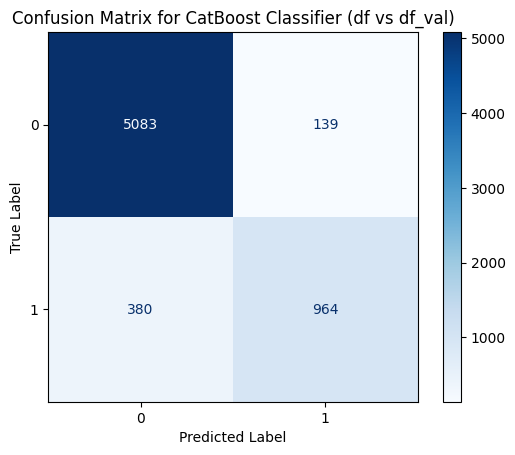

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=cat_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for CatBoost Classifier (df vs df_val)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [9]:
# 1. Prepare dataframes for the regression task
# Define the features to be used for regression (same as for classification, excluding the target and identifiers)
# 'track_popularity' is the target for regression and should not be in the features.
# The 'features_to_drop' list already includes identifiers.

# Start with the columns that were used in X_clf and remove 'track_popularity' if it's there.
features_for_regression = X_clf.columns.tolist()
if 'track_popularity' in features_for_regression:
    features_for_regression.remove('track_popularity')

# 'X_df' and 'y_df' represent the original df (training data for the regressor before internal split)
X_df = df[features_for_regression]
y_df = df['track_popularity']

# Ensure both df and df_val have these columns before selecting
X_reg_val = df_val[features_for_regression]

# Ensure categorical features are consistent (they should be, as defined previously for X_clf)
categorical_features_reg = [col for col in categorical_features_indices if col != 'track_popularity']

# 2. Generate "similarity" weights for df (training data for regressor)
# Use the pre-trained cat_clf to predict the probability of each df row belonging to class 1 (i.e., looking like df_val).
prob_is_df_val_for_df_rows = cat_clf.predict_proba(X_clf.iloc[:len(df)])[:, 1]

# Use these probabilities as sample weights for the regressor.
sample_weight_reg = prob_is_df_val_for_df_rows

# 3. Perform Train-Test Split on the 'df' data for internal evaluation
X_train, X_test, y_train, y_test, sample_weight_train, sample_weight_test = train_test_split(
    X_df, y_df, sample_weight_reg, test_size=0.2, random_state=42
)

# 4. Initialize and train CatBoostRegressor on the *training split*
cat_reg = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=5,
    loss_function='RMSE',
    eval_metric='R2',
    random_seed=42,
    verbose=100, # Show verbose output every 100 iterations
    cat_features=categorical_features_reg
)

print("\nTraining CatBoost Regressor on train split with similarity weights...")
cat_reg.fit(X_train, y_train, sample_weight=sample_weight_train)
print("CatBoost Regressor trained successfully on train split.")

# 5. Calculate and Plot R-squared scores for Train and Test sets
y_train_pred = cat_reg.predict(X_train)
y_test_pred = cat_reg.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"\nR-squared (Train): {r2_train:.4f}")
print(f"R-squared (Test): {r2_test:.4f}")

# 6. Predict track_popularity for df_val using the model trained on the internal train split
predictions_df_val = cat_reg.predict(X_reg_val)

print("\nPredictions for df_val track_popularity generated using the model trained on the split train set.")
print(f"Sample predictions for df_val track_popularity: {predictions_df_val[:5]}")


Training CatBoost Regressor on train split with similarity weights...
0:	learn: 0.0405233	total: 132ms	remaining: 1m 5s
100:	learn: 0.4596559	total: 5.68s	remaining: 22.4s
200:	learn: 0.5232952	total: 15.1s	remaining: 22.5s
300:	learn: 0.5652029	total: 20.1s	remaining: 13.3s
400:	learn: 0.5974291	total: 26.3s	remaining: 6.48s
499:	learn: 0.6246369	total: 31.1s	remaining: 0us
CatBoost Regressor trained successfully on train split.

R-squared (Train): 0.7570
R-squared (Test): 0.4750

Predictions for df_val track_popularity generated using the model trained on the split train set.
Sample predictions for df_val track_popularity: [27.02944916 30.56131607 28.59209874 34.61382136 50.53650474]


R-squared (Train): 0.7446
R-squared (Test): 0.4673

In [13]:
cat_reg.get_feature_importance(prettified=True)

,Feature Id,Importances
0,track_album_id,21.911076
1,track_artist,14.347167
2,grupo_anio,4.384371
3,tonality,3.701007
4,len_playlist_name,3.412901
...,...,...
81,distance_mean_liveness,0.099789
82,z_valence,0.058749
83,distance_mean_duration_ms,0.043634
84,log_speechiness,0.041635


Guardamos predicciones

In [12]:
adv_val_pred = pd.DataFrame({'ID':df_val['Unnamed: 0'], 'track_popularity': predictions_df_val})
adv_val_pred.to_csv('adv_val_pred.csv', index=False)

Ponderamos

In [21]:
df_ponderado_prob_ser_val = pd.DataFrame(
    {'Predicciones': predictions_df_val,
     'Prob': (cat_clf.predict_proba(X_reg_val.iloc[:len(df)])[:, 1])
     }
)

df_ponderado_prob_NO_ser_val = pd.DataFrame(
    {'Predicciones': predictions_df_val,
     'Prob': (1- (cat_clf.predict_proba(X_reg_val.iloc[:len(df)])[:, 1]))
     }
)

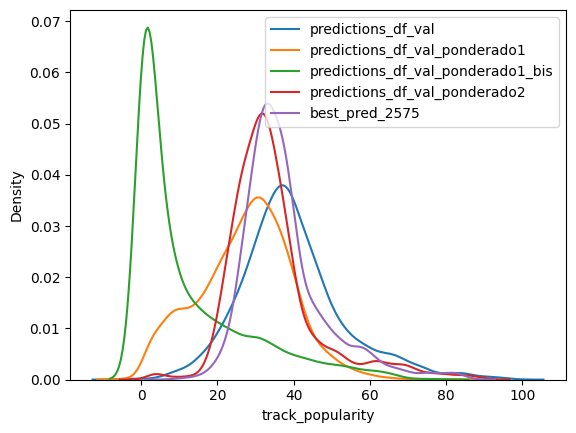

In [54]:
best_pred_2575 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/avg_leak_plus_track_id_2575.csv')
catboost_0 = pd.read_csv('https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Submissions/submission_catboost0.csv')

sns.kdeplot(predictions_df_val)
sns.kdeplot(df_ponderado_prob_ser_val['Predicciones']*df_ponderado_prob_ser_val['Prob'])
# sns.kdeplot((df_ponderado_prob_ser_val['Prob']*2)*predictions_df_val)
sns.kdeplot(df_ponderado_prob_NO_ser_val['Predicciones']*df_ponderado_prob_NO_ser_val['Prob'])
sns.kdeplot(best_pred_2575['track_popularity'])
sns.kdeplot(catboost_0['track_popularity'])

plt.legend(['predictions_df_val','predictions_df_val_ponderado1','predictions_df_val_ponderado1_bis','predictions_df_val_ponderado2', 'best_pred_2575', 'catboost_0'])
plt.show()

In [28]:
pd.concat([
    pd.DataFrame(predictions_df_val).describe(),
    (df_ponderado_prob_ser_val['Predicciones']*df_ponderado_prob_ser_val['Prob']).describe(),
    (df_ponderado_prob_NO_ser_val['Predicciones']*df_ponderado_prob_NO_ser_val['Prob']).describe(),
    best_pred_2575['track_popularity'].describe(),
    catboost_0['track_popularity'].describe()
], axis=1)

,0,0,1,track_popularity,track_popularity
count,6567.000000,6567.000000,6567.000000,6567.000000,6567.000000
mean,39.540780,27.315144,12.225636,34.607000,37.564554
std,13.799454,12.163110,15.139265,12.065613,10.962890
min,-5.594975,-5.270531,-0.324444,0.615688,6.980352
25%,31.093496,19.282829,1.195899,27.387843,30.743261
50%,37.924217,28.399236,5.309985,32.308640,35.282322
75%,45.842043,35.525013,18.584296,37.882575,41.043516
max,98.413633,82.539760,78.027742,90.452455,87.131911


In [40]:
df_ponderado1 = pd.DataFrame(
    {'ID': df_val['Unnamed: 0'],
     'track_popularity': (df_ponderado_prob_ser_val['Predicciones']*df_ponderado_prob_ser_val['Prob'])}
)
df_ponderado1['track_popularity'] = df_ponderado1['track_popularity'].apply(lambda x: x if x >= 0 else 0)
df_ponderado1[['ID','track_popularity']].to_csv('adversarial_val_ponderado1.csv', index=False)